In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt
from scipy.stats import skew, kurtosis
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    StratifiedKFold)
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve)
import joblib
import os
import glob

DATA_DIR = '../data/physionet_gait/'
FS = 100  # sampling rate is 100 Hz

# ── COUNT FILES ────────────────────────────────────────────
all_files = glob.glob(
    os.path.join(DATA_DIR, '*.txt'))

# Skip non-data files
skip_files = [
    'SHA256SUMS.txt',
    'demographics.txt',
    'format.txt'
]
all_files = [
    f for f in all_files
    if os.path.basename(f) not in skip_files
]

# Separate healthy and Parkinson's
# Co = Control (Healthy)
# Pt = Patient (Parkinson's)
healthy_files = [
    f for f in all_files if 'Co' in
    os.path.basename(f)
]
parkinson_files = [
    f for f in all_files if 'Pt' in
    os.path.basename(f)
]

print(f"Total files found:   {len(all_files)}")
print(f"Healthy files (Co):  {len(healthy_files)}")
print(f"Parkinson files(Pt): {len(parkinson_files)}")

# Look at one file
sample = pd.read_csv(
    parkinson_files[0],
    sep='\s+',
    header=None
)
print(f"\nFirst PD file: "
      f"{os.path.basename(parkinson_files[0])}")
print(f"Shape: {sample.shape}")
print(f"Columns: {sample.shape[1]}")
print(f"\nFirst 3 rows:")
print(sample.head(3))

Total files found:   306
Healthy files (Co):  92
Parkinson files(Pt): 214

First PD file: GaPt03_01.txt
Shape: (12119, 19)
Columns: 19

First 3 rows:
     0      1       2       3      4      5      6      7     8    9    10  \
0  0.00  71.72  174.90  135.96  83.38  30.14  64.57  84.04  35.2  0.0  0.0   
1  0.01  71.72  174.90  135.96  83.38  30.14  64.57  84.04  35.2  0.0  0.0   
2  0.02  71.72  173.25  134.31  84.92  31.68  64.57  87.78  35.2  0.0  0.0   

    11   12   13   14   15   16      17   18  
0  0.0  0.0  0.0  0.0  0.0  0.0  679.91  0.0  
1  0.0  0.0  0.0  0.0  0.0  0.0  679.91  0.0  
2  0.0  0.0  0.0  0.0  0.0  0.0  683.43  0.0  


In [2]:
# ── FUNCTIONS ──────────────────────────────────────────────

def load_gait_file(filepath):
    """Load one gait file"""
    try:
        df = pd.read_csv(
            filepath,
            sep='\s+',
            header=None
        )
        df = df.apply(pd.to_numeric,
                      errors='coerce')
        df = df.fillna(0)
        
        if df.shape[1] < 19:
            return None, None, None
        
        time  = df.iloc[:, 0].values
        left  = df.iloc[:, 17].values
        right = df.iloc[:, 18].values
        
        return time, left, right
    
    except Exception as e:
        return None, None, None

def detect_steps(force_signal, fs=100):
    """Detect footstrikes from force signal"""
    if len(force_signal) < fs:
        return np.array([])
    
    # Low pass filter
    b, a = butter(4, 10/(fs/2), btype='low')
    filtered = filtfilt(b, a, force_signal)
    
    mean_force = np.mean(filtered)
    std_force  = np.std(filtered)
    
    if mean_force <= 0:
        return np.array([])
    
    peaks, _ = find_peaks(
        filtered,
        height=mean_force * 0.3,
        distance=int(fs * 0.3),
        prominence=std_force * 0.3
    )
    return peaks

def extract_gait_features(filepath, fs=100):
    """
    Extract 15 gait features from one file
    """
    time, left, right = load_gait_file(filepath)
    
    if time is None:
        return None
    
    if len(left) < fs * 10:
        return None
    
    # Detect steps
    l_peaks = detect_steps(left,  fs)
    r_peaks = detect_steps(right, fs)
    
    if len(l_peaks) < 4 or len(r_peaks) < 4:
        return None
    
    # Stride times in seconds
    l_strides = np.diff(l_peaks) / fs
    r_strides = np.diff(r_peaks) / fs
    
    # Remove unrealistic strides
    # Normal stride = 0.5 to 3.0 seconds
    l_strides = l_strides[
        (l_strides > 0.3) & (l_strides < 4.0)]
    r_strides = r_strides[
        (r_strides > 0.3) & (r_strides < 4.0)]
    
    if len(l_strides) < 2 or \
       len(r_strides) < 2:
        return None
    
    all_strides = np.concatenate([
        l_strides, r_strides])
    
    # Basic stats
    mean_stride = np.mean(all_strides)
    std_stride  = np.std(all_strides)
    cv_stride   = std_stride / (
        mean_stride + 1e-10)
    
    # Cadence — steps per minute
    total_steps = len(l_peaks) + len(r_peaks)
    total_time  = len(left) / fs
    cadence     = (total_steps / total_time) * 60
    
    # Symmetry — left vs right difference
    min_len = min(len(l_strides),
                  len(r_strides))
    symmetry = np.mean(np.abs(
        l_strides[:min_len] -
        r_strides[:min_len]
    )) / (mean_stride + 1e-10)
    
    # Step heights — shuffle detection
    b, a = butter(4, 10/(fs/2), btype='low')
    left_f  = filtfilt(b, a, left)
    right_f = filtfilt(b, a, right)
    
    l_heights = left_f[l_peaks] \
        if len(l_peaks) > 0 else [0]
    r_heights = right_f[r_peaks] \
        if len(r_peaks) > 0 else [0]
    
    all_heights = np.concatenate([
        l_heights, r_heights])
    mean_height = np.mean(all_heights)
    max_height  = np.max(all_heights)
    shuffle_idx = 1 - (
        mean_height / (max_height + 1e-10))
    
    # Freezing — strides longer than 3 seconds
    freeze_count = int(np.sum(
        all_strides > 3.0))
    freeze_ratio = freeze_count / (
        len(all_strides) + 1e-10)
    
    # Stride acceleration
    stride_accel = np.std(np.diff(all_strides)) \
        if len(all_strides) > 2 else 0
    
    # Double support estimate
    all_step_times = np.sort(np.concatenate([
        l_peaks/fs, r_peaks/fs]))
    step_intervals = np.diff(all_step_times) \
        if len(all_step_times) > 1 \
        else np.array([0.5])
    double_support = np.mean(
        step_intervals) / (mean_stride + 1e-10)
    
    features = [
        mean_stride,
        std_stride,
        cv_stride,
        np.min(all_strides),
        np.max(all_strides),
        np.percentile(all_strides, 75) -
        np.percentile(all_strides, 25),
        cadence,
        symmetry,
        shuffle_idx,
        float(freeze_count),
        freeze_ratio,
        stride_accel,
        double_support,
        float(skew(all_strides)),
        float(kurtosis(all_strides))
    ]
    
    # Check for NaN or Inf
    features = np.array(features)
    if np.any(np.isnan(features)) or \
       np.any(np.isinf(features)):
        return None
    
    return features.tolist()

feature_names = [
    'mean_stride',
    'std_stride',
    'cv_stride',
    'min_stride',
    'max_stride',
    'iqr_stride',
    'cadence',
    'symmetry_index',
    'shuffle_index',
    'freeze_count',
    'freeze_ratio',
    'stride_acceleration',
    'double_support',
    'stride_skewness',
    'stride_kurtosis'
]

print(f"Extracting features from "
      f"{len(all_files)} files...")
print()

all_features = []
all_labels   = []
failed       = 0

for filepath in sorted(all_files):
    fname = os.path.basename(filepath)
    
    features = extract_gait_features(
        filepath, FS)
    
    if features is not None:
        all_features.append(features)
        
        # Label from filename
        if 'Pt' in fname:
            all_labels.append(1)  # Parkinson's
        else:
            all_labels.append(0)  # Healthy
    else:
        failed += 1

X = np.array(all_features)
y = np.array(all_labels)

print(f"Successfully loaded: {len(X)}")
print(f"Failed/skipped:      {failed}")
print(f"Parkinson's:         {np.sum(y==1)}")
print(f"Healthy:             {np.sum(y==0)}")
print(f"Features:            {X.shape[1]}")

Extracting features from 306 files...

Successfully loaded: 306
Failed/skipped:      0
Parkinson's:         214
Healthy:             92
Features:            15


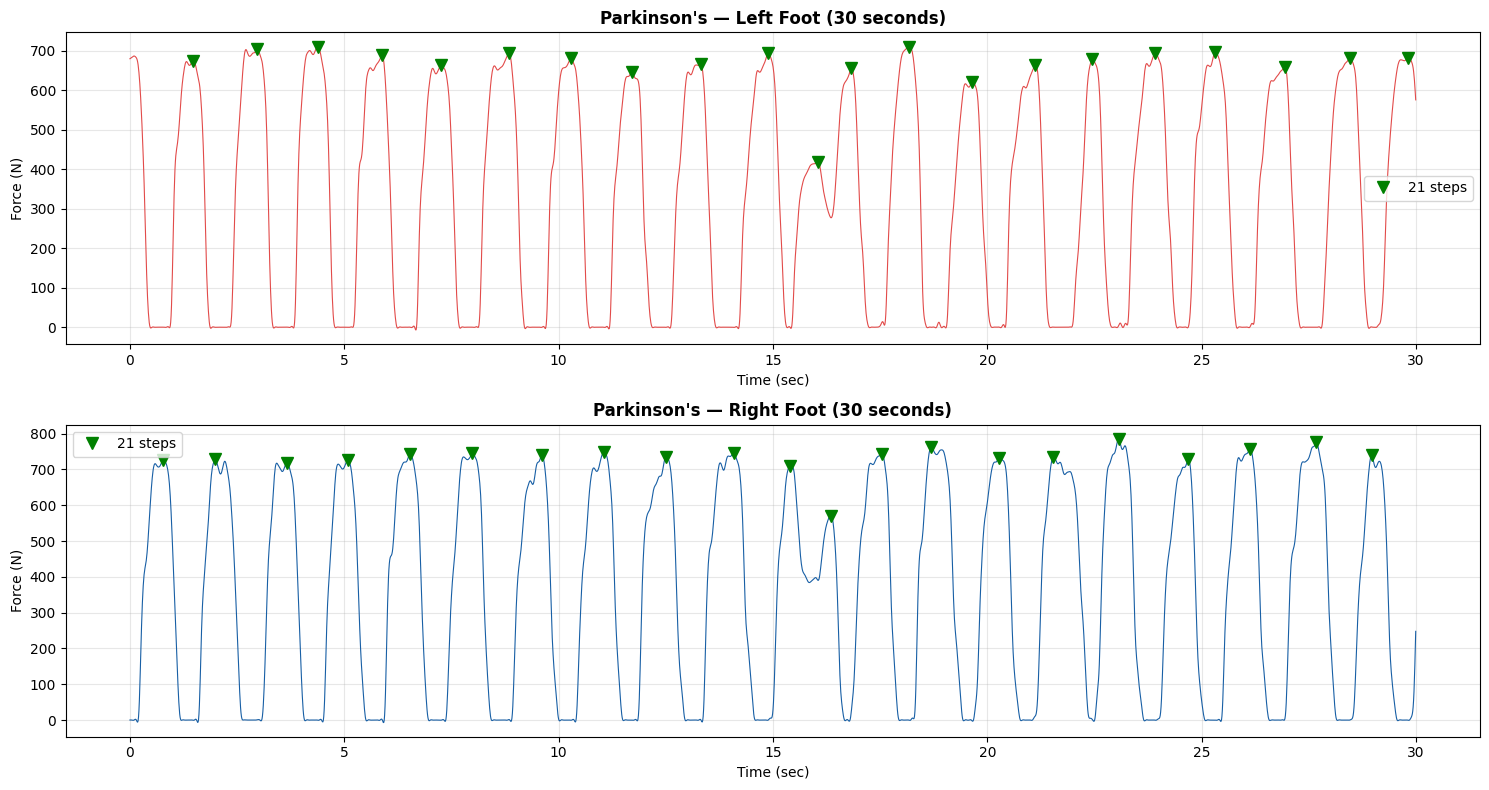

C:\Users\nihal\AppData\Local\Temp\ipykernel_7928\2254163377.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\nihal\AppData\Local\Temp\ipykernel_7928\2254163377.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\nihal\AppData\Local\Temp\ipykernel_7928\2254163377.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\nihal\AppData\Local\Temp\ipykernel_7928\2254163377.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


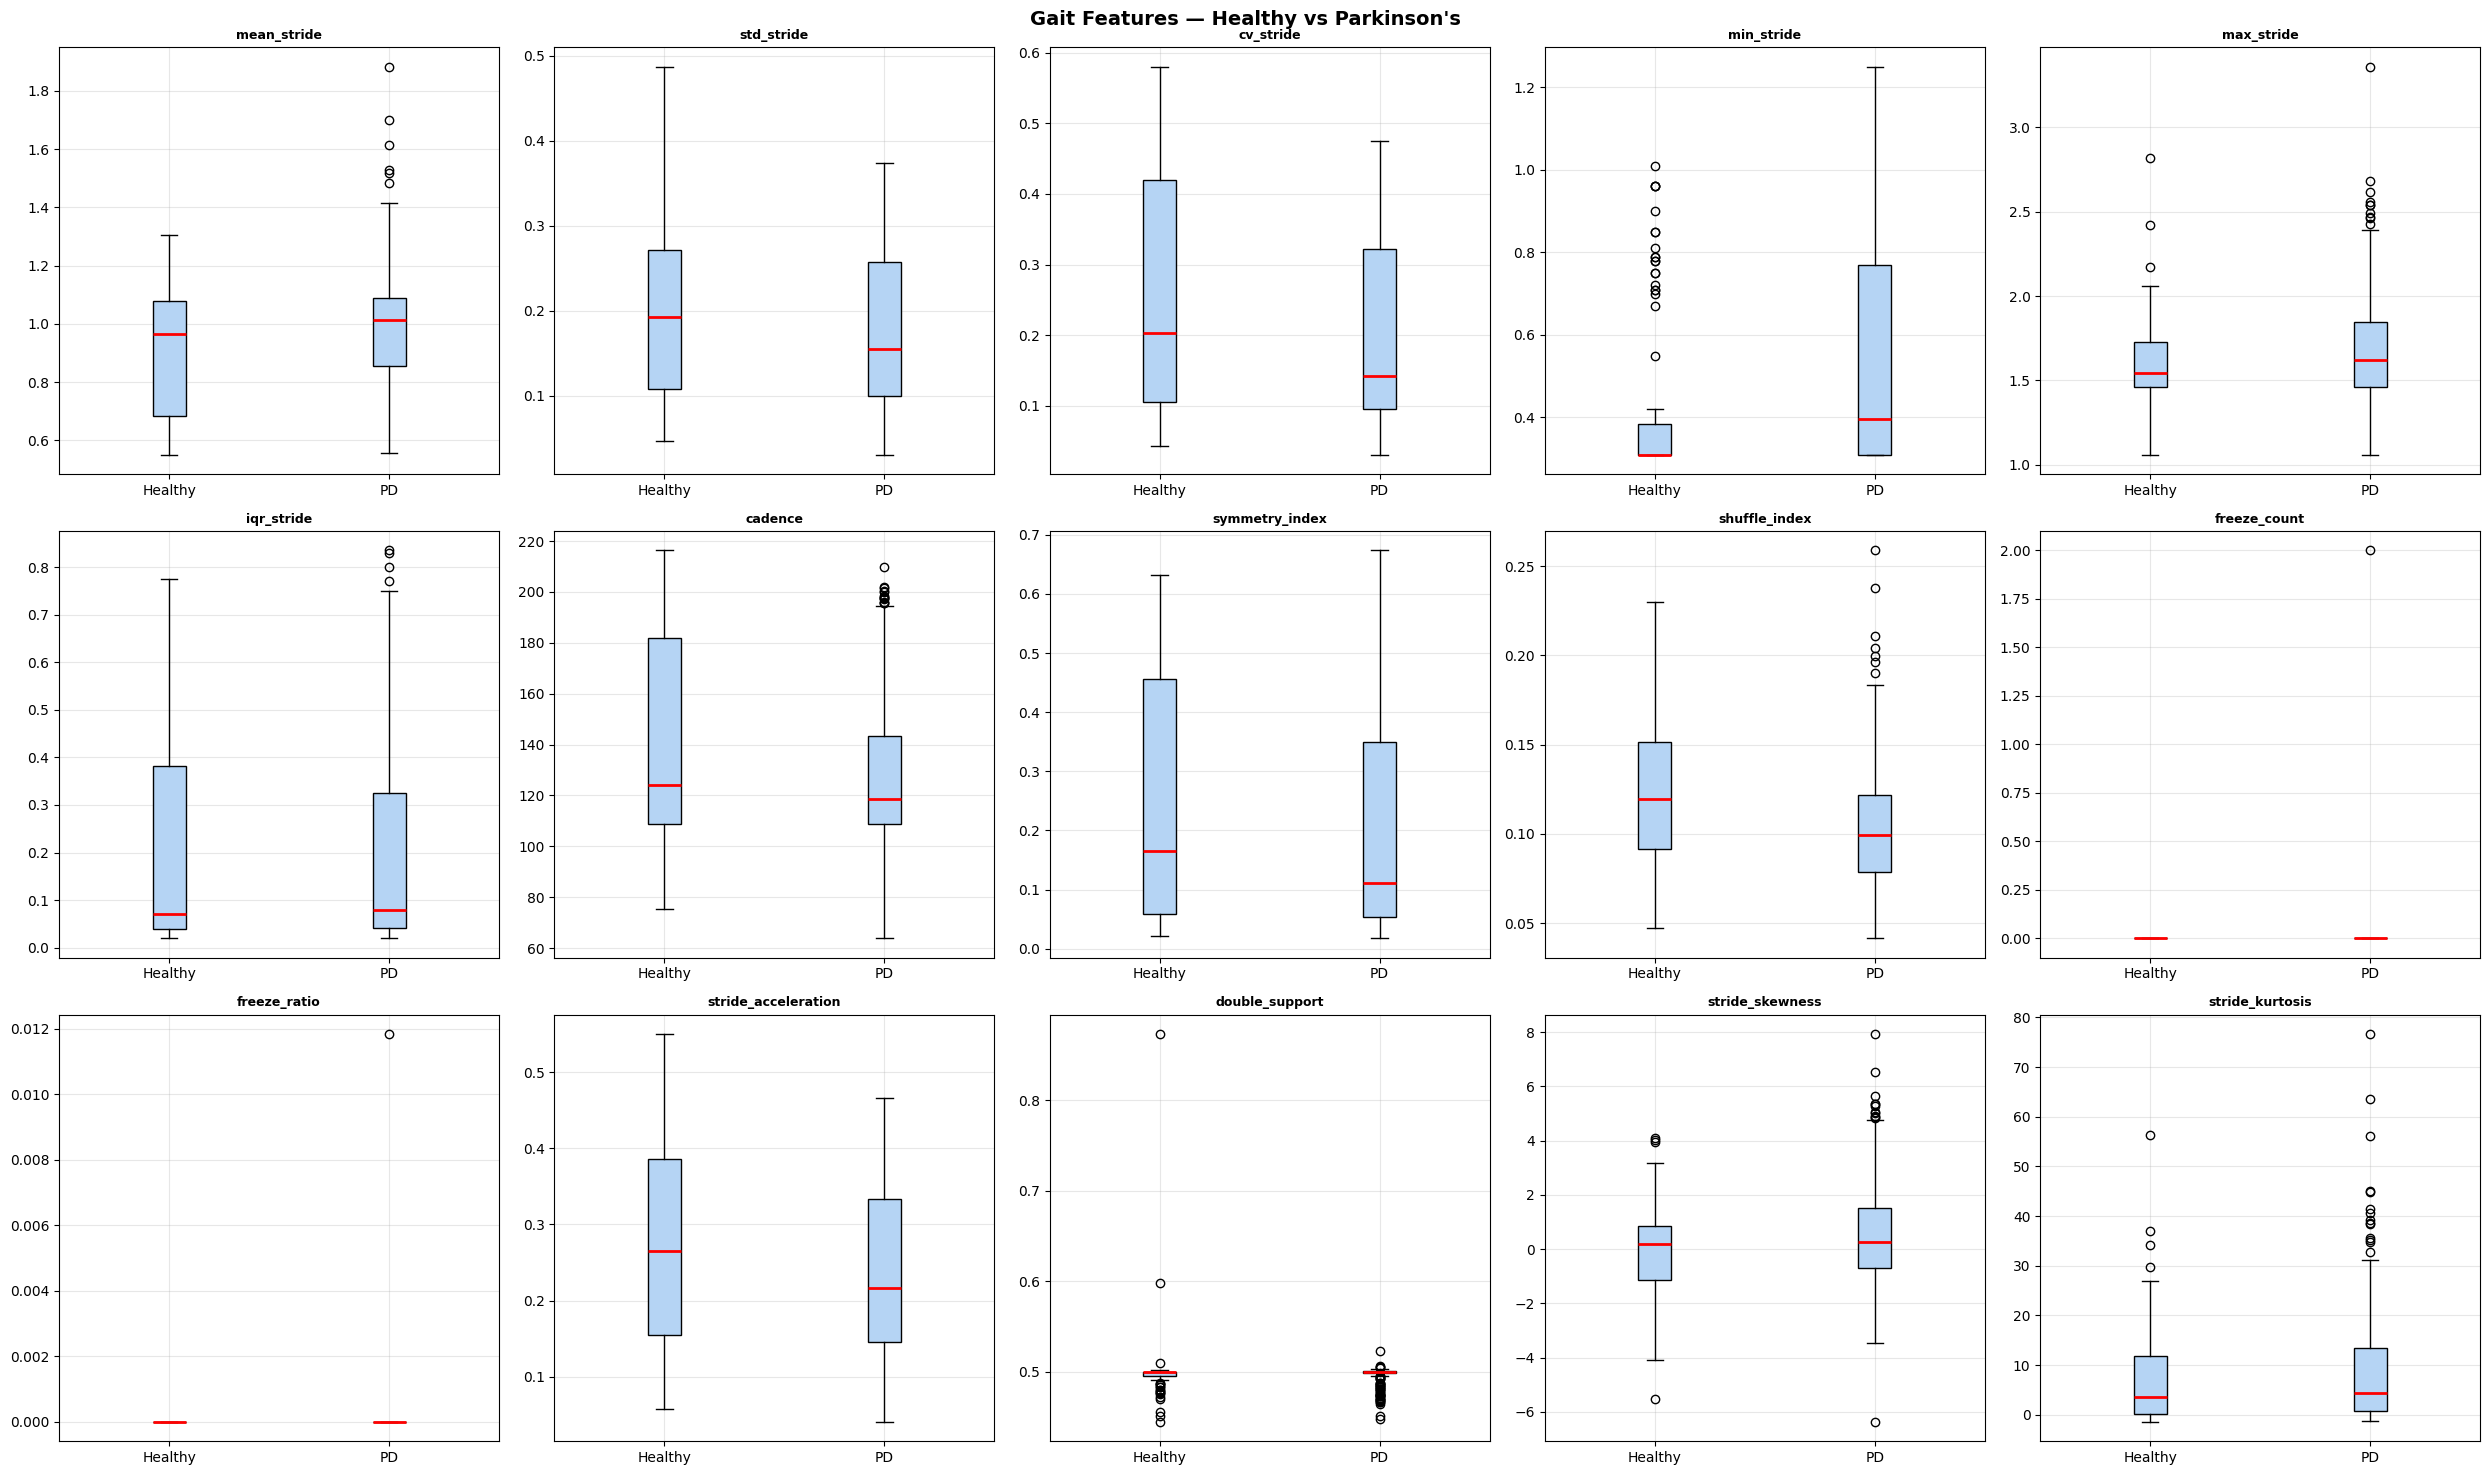


Feature                   Healthy         PD
--------------------------------------------
mean_stride                0.8976     0.9864
std_stride                 0.1995     0.1796
cv_stride                  0.2555     0.2027
min_stride                 0.4253     0.5363
max_stride                 1.5937     1.6893
iqr_stride                 0.2320     0.1856
cadence                  143.4344   127.9566
symmetry_index             0.2522     0.1969
shuffle_index              0.1217     0.1049
freeze_count               0.0000     0.0093
freeze_ratio               0.0000     0.0001
stride_acceleration        0.2731     0.2355
double_support             0.4999     0.4960
stride_skewness           -0.0386     0.6898
stride_kurtosis            7.4837     9.3018


In [3]:
# ── VISUALISE STEP DETECTION ───────────────────────────────
# Show what the signal looks like

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Load one Parkinson's file
t, l, r = load_gait_file(parkinson_files[0])
if t is not None:
    time_30s = 30 * FS
    l_30 = l[:time_30s]
    r_30 = r[:time_30s]
    
    b, a = butter(4, 10/(FS/2), btype='low')
    l_f = filtfilt(b, a, l_30)
    r_f = filtfilt(b, a, r_30)
    
    l_peaks = detect_steps(l_30, FS)
    r_peaks = detect_steps(r_30, FS)
    
    time_axis = np.arange(time_30s) / FS
    
    axes[0].plot(time_axis, l_f,
                 color='#E24B4A', lw=0.8)
    axes[0].plot(l_peaks/FS, l_f[l_peaks],
                 'gv', ms=8,
                 label=f'{len(l_peaks)} steps')
    axes[0].set_title(
        "Parkinson's — Left Foot "
        "(30 seconds)",
        fontweight='bold')
    axes[0].set_xlabel('Time (sec)')
    axes[0].set_ylabel('Force (N)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(time_axis, r_f,
                 color='#185FA5', lw=0.8)
    axes[1].plot(r_peaks/FS, r_f[r_peaks],
                 'gv', ms=8,
                 label=f'{len(r_peaks)} steps')
    axes[1].set_title(
        "Parkinson's — Right Foot "
        "(30 seconds)",
        fontweight='bold')
    axes[1].set_xlabel('Time (sec)')
    axes[1].set_ylabel('Force (N)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/gait_step_detection.png',
            dpi=150)
plt.show()

# Feature comparison boxplots
df = pd.DataFrame(X, columns=feature_names)
df['label'] = y

fig, axes = plt.subplots(3, 5, figsize=(25, 15))

for ax, feat in zip(axes.flat, feature_names):
    h = df[df['label']==0][feat].values
    p = df[df['label']==1][feat].values
    
    ax.boxplot(
        [h, p],
        labels=['Healthy', 'PD'],
        patch_artist=True,
        boxprops=dict(facecolor='#B5D4F4'),
        medianprops=dict(color='red', lw=2)
    )
    ax.set_title(feat, fontsize=9,
                  fontweight='bold')
    ax.grid(True, alpha=0.3)

for ax in list(axes.flat)[len(feature_names):]:
    ax.set_visible(False)

plt.suptitle(
    'Gait Features — Healthy vs Parkinson\'s',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/gait_features.png',
            dpi=150)
plt.show()

# Print mean comparison
print(f"\n{'Feature':<22} {'Healthy':>10}"
      f" {'PD':>10}")
print("-" * 44)
for f in feature_names:
    h = df[df['label']==0][f].mean()
    p = df[df['label']==1][f].mean()
    print(f"{f:<22} {h:>10.4f} {p:>10.4f}")

In [4]:
# ── SPLIT ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"Train PD:      {np.sum(y_train==1)}")
print(f"Train Healthy: {np.sum(y_train==0)}")

# ── PIPELINE ───────────────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        probability=True,
        random_state=42,
        class_weight='balanced'
    ))
])

param_grid = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C':      [0.1, 1, 10, 100],
    'svm__gamma':  ['scale', 'auto',
                    0.001, 0.01, 0.1]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("\nTraining SVM...")
grid.fit(X_train, y_train)

print(f"\nBest params: {grid.best_params_}")
print(f"Best CV AUC: {grid.best_score_:.4f}")
best_model = grid.best_estimator_

Train: (244, 15)
Test:  (62, 15)
Train PD:      171
Train Healthy: 73

Training SVM...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best params: {'svm__C': 100, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV AUC: 0.7196


Training Random Forest...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best RF params: {'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_split': 10, 'rf__n_estimators': 200}
Best RF CV AUC: 0.7272

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.78      0.37      0.50        19
           1       0.77      0.95      0.85        43

    accuracy                           0.77        62
   macro avg       0.78      0.66      0.68        62
weighted avg       0.77      0.77      0.75        62

Test AUC Score: 0.8115


C:\Users\nihal\AppData\Local\Temp\ipykernel_7928\273685086.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="viridis")


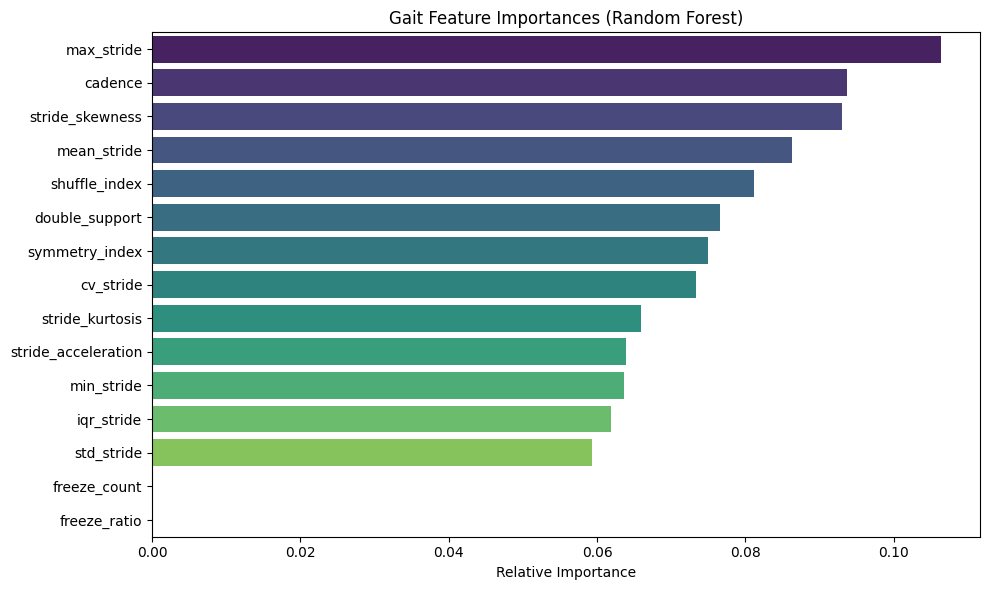

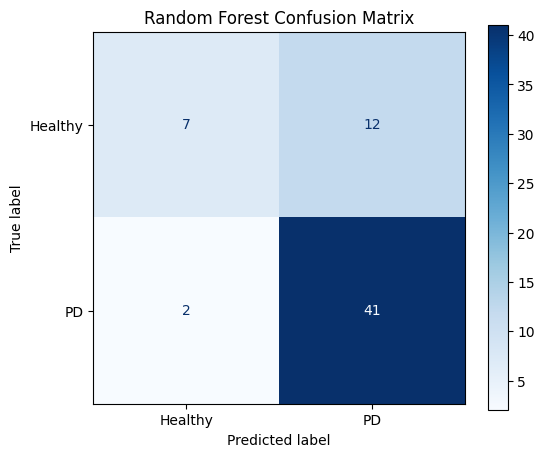

In [5]:
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

# ── RANDOM FOREST PIPELINE ──────────────────────────────────
rf_pipeline = Pipeline([
    # Note: RF doesn't strictly need scaling, but it's good practice in pipelines
    ('scaler', StandardScaler()), 
    ('rf', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

rf_param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth':    [None, 10, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Training Random Forest...")
rf_grid.fit(X_train, y_train)

print(f"\nBest RF params: {rf_grid.best_params_}")
print(f"Best RF CV AUC: {rf_grid.best_score_:.4f}")

# ── EVALUATION ─────────────────────────────────────────────
best_rf = rf_grid.best_estimator_
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred))
print(f"Test AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# ── FEATURE IMPORTANCE ─────────────────────────────────────
importances = best_rf.named_steps['rf'].feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Gait Feature Importances (Random Forest)")
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="viridis")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

# ── CONFUSION MATRIX ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, 
                                     display_labels=["Healthy", "PD"], 
                                     cmap="Blues", ax=ax)
plt.title("Random Forest Confusion Matrix")
plt.show()


In [7]:
import os
import joblib

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the Random Forest model
# Note: Using 'best_rf' which was the best estimator from our RF grid search
joblib.dump(best_rf, '../models/gait_model.pkl')

# Save the feature names so the API knows what order to feed the data
joblib.dump(feature_names, '../models/gait_feature_names.pkl')

print("Saved Random Forest Model:")
print("  ../models/gait_model.pkl")
print("  ../models/gait_feature_names.pkl")

# Verify the save
loaded_model = joblib.load('../models/gait_model.pkl')
print(f"\nModel verification:")
print(f"  Loaded Model Type: {type(loaded_model.named_steps['rf'])}")
print(f"  Classes: {loaded_model.classes_} (0=Healthy, 1=PD)")


Saved Random Forest Model:
  ../models/gait_model.pkl
  ../models/gait_feature_names.pkl

Model verification:
  Loaded Model Type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
  Classes: [0 1] (0=Healthy, 1=PD)
